# Paso a paso para construir un modelo ARIMA

Cómo abordar un problema de generación de pronósticos con ARIMA, con lo cual veremos las decisiones a las que convencionalmente nos tendremos que enfrentar si usamos datos reales.

## 1. Objetivo de este ejercicio

> Entrenar, validar y poner a prueba un modelo ARIMA para pronosticar el comportamiento del índice S&P 500

## 2. El set de datos y el problema a resolver

Para entender las particularidades de este ejercicio, comencemos importando las librerías necesarias y cargando el set de datos:

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import Naive, ARIMA # <--- Näive: modelo base
import statsmodels.api as sm

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

In [2]:
# Lectura de la serie de tiempo
df = pd.read_csv('datos/S&P_500.csv', parse_dates=["ds"])
df

,unique_id,ds,y
0,S&P 500,2020-06-01,3055.729980
1,S&P 500,2020-06-02,3080.820068
2,S&P 500,2020-06-03,3122.870117
3,S&P 500,2020-06-04,3112.350098
4,S&P 500,2020-06-05,3193.929932
...,...,...,...
1400,S&P 500,2025-12-24,6932.049805
1401,S&P 500,2025-12-26,6929.939941
1402,S&P 500,2025-12-29,6905.740234
1403,S&P 500,2025-12-30,6896.240234


La Serie de Tiempo contiene el registro histórico (frecuencia diaria, días laborales) desde el 1 de junio de 2020 hasta el 25 de diciembre de 2025.

Veamos el comportamiento en el tiempo de esta Serie:

<Axes: xlabel='ds', ylabel='y'>

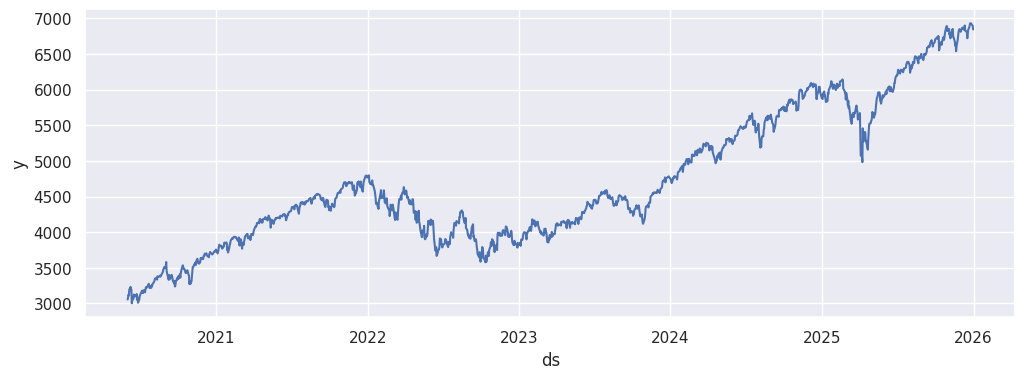

In [3]:
sns.lineplot(df, x="ds", y="y")

Evidentemente es una Serie no estacionaria.

Así que para este caso supondremos que el problema a resolver es **desarrollar un modelo predictivo para pronosticar el comportamiento del S&P 500 con un horizonte de 5 días**.

Antes de resolver este problema, veamos los pasos que usualmente deberíamos tener en cuenta (esto aplica para el desarrollo de cualquier tipo de modelo predictivo, incluyendo ARIMA).

## 3. Los pasos involucrados en el desarrollo de un modelo predictivo (caso especial ARIMA)

1. Definir claramente el problema de predicción
2.  Explorar y realizar limpieza de los datos
3. Entrenar y validar un simple modelo base (o de referencia)
4. Definir el tipo de modelo predictivo a implementar (teniendo en cuenta las características de la Serie)
5. Verificar si se cumplen los supuestos del modelo
6. Seleccionar el mejor conjunto de hiper-parámetros del modelo
7. Validar el modelo y comparar su desempeño con el del modelo base (3)
8. Generar pronósticos con el modelo seleccionado en el paso anterior

Veamos en detalle los pasos del 3 al 8.

## 4. Paso 3: entrenar y validar un simple modelo base

Este modelo base será usado como referencia.

Dependiendo de las características de la Serie de Tiempo, lo que se sugiere es usar uno de los [métodos simples para generación de pronósticos](https://codificandobits.com/curso/pronosticos-series-de-tiempo-regresion/2-metodos-simples-generacion-pronosticos/) que vimos en la lección 2 del curso "Pronósticos de Series de Tiempo con Regresión".

Estos métodos son: media histórica, näive, näive estacional y deriva.

En este caso (acciones en la bolsa) el método Näive es el método recomendado. En este método el siguiente valor pronosticado (o el pronóstico para una ventana "h") es simplemente la última observación:

$$y_{t+h} = y_t$$

Así que la idea es construir y evaluar el desempeño de este modelo con nuestra Serie de Tiempo y luego usar estas métricas como referencia para modelos más sofisticados.

Como queremos pronosticar 5 días a futuro, tomaremos todos los datos históricos exceptuando los últimos 5 y este será nuestro set de entrenamiento. Y el set de prueba (que mantendremos oculto) serán simplemente los últimos 5 registros históricos:

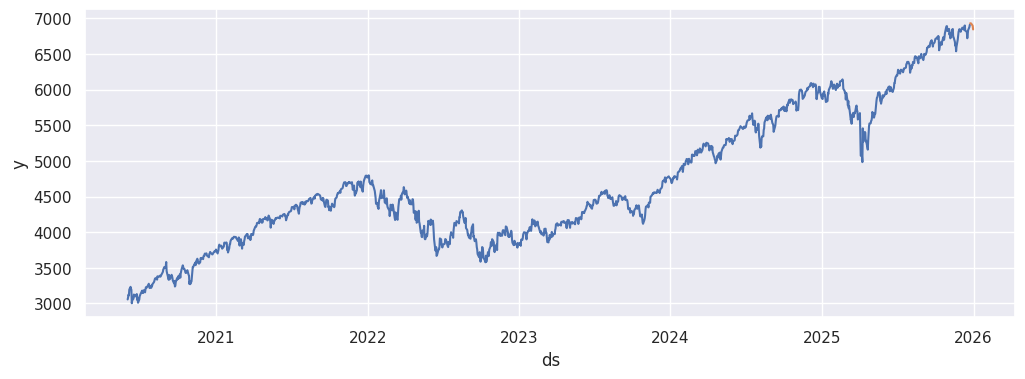

In [4]:
N = len(df)
df_tr = df[:N-5] # Train
df_ts = df[N-5:] # Prueba

# Gráfico series de entrenamiento y prueba
sns.lineplot(df_tr, x="ds", y="y");
sns.lineplot(df_ts, x="ds", y="y");

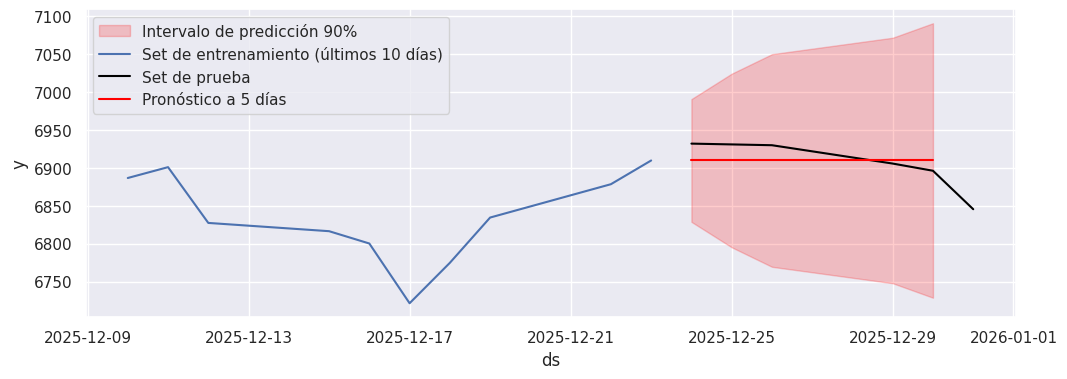

In [5]:
# Crear instancia del modelo Näive y entrenarlo con los datos de entrenamiento
sf_naive = StatsForecast(models = [Naive(alias='Naive')], freq='B')
sf_naive.fit(df_tr)

# Pronóstico a 5 días laborales
fc_naive = sf_naive.forecast(df=df_tr, h=5, level=[90])

# Graficar última parte del set de entrenamiento, datos de prueba, pronóstico Näive e intervalo de predicción
fig, ax = plt.subplots()
plt.fill_between(x=fc_naive["ds"],
                 y1 = fc_naive['Naive-lo-90'],
                 y2 = fc_naive['Naive-hi-90'],
                 color = 'red',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90%');
sns.lineplot(df_tr[-10:], x="ds", y="y", label='Set de entrenamiento (últimos 10 días)');
sns.lineplot(df_ts, x="ds", y="y", color='black', label='Set de prueba');
sns.lineplot(fc_naive, x="ds", y="Naive", color='red', label='Pronóstico a 5 días');

Y es una línea horizontal porque el pronóstico es simplemente una réplica (5 veces) del último valor real de la Serie.

Hagamos la validación cruzada de este simple modelo. En esta validación cruzada mediremos el RMSE y el MAPE (media y desviación estándar):

In [6]:
# Validación cruzada
# - Ventanas de origen fijo
# - El número de datos se irá incrementando
# - Número de ventanas: 24
# - Horizonte de predicción: 5 días
# - Tamaño del paso: 10

cv_df_naive = sf_naive.cross_validation(
    df=df_tr, # Set de entrenamiento
    h=5, # Horizonte
    step_size=10,
    n_windows=24
)
cv_df_naive

,unique_id,ds,cutoff,y,Naive
0,S&P 500,2025-01-17,2025-01-16,5996.660156,5937.339844
1,S&P 500,2025-01-21,2025-01-16,6049.240234,5937.339844
2,S&P 500,2025-01-22,2025-01-16,6086.370117,5937.339844
3,S&P 500,2025-01-23,2025-01-16,6118.709961,5937.339844
4,S&P 500,2025-01-24,2025-01-16,6101.240234,5937.339844
...,...,...,...,...,...
115,S&P 500,2025-12-17,2025-12-16,6721.430176,6800.259766
116,S&P 500,2025-12-18,2025-12-16,6774.759766,6800.259766
117,S&P 500,2025-12-19,2025-12-16,6834.500000,6800.259766
118,S&P 500,2025-12-22,2025-12-16,6878.490234,6800.259766


Ahora la idea es evaluar el RMSE/MAPE en cada ventana y luego promediar y obtener la desviación estándar de estos valores:

In [7]:
def metricas_cv(cv_df, nombres_modelos):
    resultados = []

    # Iterar por cada modelo (si hay más de uno)
    for modelo in nombres_modelos:
        # Agrupar por "cutoff" para calcular métricas por ventana
        metricas_ventana = []

        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y'] # Observación
            y_pred = ventana[modelo] # Pronóstico

            # Calcular y almacenarRMSE y MAPE para la ventana
            rmse = np.sqrt(np.mean((y_true - y_pred)**2))
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

            metricas_ventana.append({'rmse': rmse, 'mape': mape})

        # Convertir resultados anteriores a DataFrame de Pandas
        metricas_df = pd.DataFrame(metricas_ventana)

        resultados.append({
            'Modelo': modelo,
            'RMSE_media': metricas_df['rmse'].mean(),
            'RMSE_std': metricas_df['rmse'].std(),
            'MAPE_media(%)': metricas_df['mape'].mean(),
            'MAPE_std(%)': metricas_df['mape'].std()
        })

    return pd.DataFrame(resultados)

Usemos la función anterior para calcular las métricas:

In [8]:
metricas_naive = metricas_cv(cv_df_naive, [sf_naive.models[0].alias])
metricas_naive

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
0,Naive,82.381626,67.54466,1.145956,1.044529


El modelo Näive no lo hace nada mal:

- Su error RMSE medio es de 82.4 USD  +- 67.5 USD. Si asumimos una media en la Serie de 5.000 USD, este error +- desviación son del orden de 1.6% +- 1.4%
- Y esto coincide con el bajo MAPE obtenido: 1.14 +- 1.04 %

Esta es nuestra referencia. Más adelante volveremos a estos valores cuando usemos nuestro modelo ARIMA.

## 5. Paso 4: definir el tipo de modelo predictivo a implementar

## 6. Paso 5: verificar si se cumplen los supuestos del modelo

En nuestro caso:

- La Serie no tiene estacionalidad
- La Serie es no estacionaria
- **Probablemente la Serie está afectada por variaciones aleatorias** (que podrían ser modeladas por el componente "MA" de ARIMA)

Así que ARIMA podría ser una opción en este caso.

Además, vemos que las condiciones anteriores satisfacen los supuestos de un modelo ARIMA (paso 5).

## 7. Paso 6: seleccionar el mejor conjunto de hiper-parámetros del modelo

Este es uno de los pasos clave en esta lección.

En este caso debemos seleccionar los órdenes "p" (para el componente AR), "d" (para el orden de diferenciación) y "q" (para el componente MA).

Acá usaremos un procedimiento similar al de la lección anterior. Comencemos viendo el orden de diferenciación:

In [9]:
# La misma función usada en la lección anterior
def prueba_diferenciacion(serie, d, titulo):
    # Eliminar posibles NaN de la serie
    serie = serie.dropna()

    # Diferenciar (si d!=0)
    if d != 0:
        for _ in range(d):
            serie = serie.diff()

    # Aplicar prueba y mostrar resultado
    resultado = adfuller(serie.dropna())
    pval = resultado[1]

    if pval < 0.05:
        # Se rechaza la hipótesis nula: la serie es estacionaria
        print(f'La serie es estacionaria porque p = {pval:.2f} < 0.05. NO se requiere diferenciación')
    else:
        # Se acepta la hipótesis nula: la serie es NO estacionaria
        print(f'La serie NO es estacionaria porque p = {pval:.2f} >= 0.05. Se requiere diferenciación')

    # Graficar
    fig, ax = plt.subplots(1,1,figsize=(12,4))
    plt.plot(range(1,len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin=1, xmax=len(serie)+1, color='red', linestyle='--');
    ax.set_title(titulo)

La serie NO es estacionaria porque p = 0.96 >= 0.05. Se requiere diferenciación


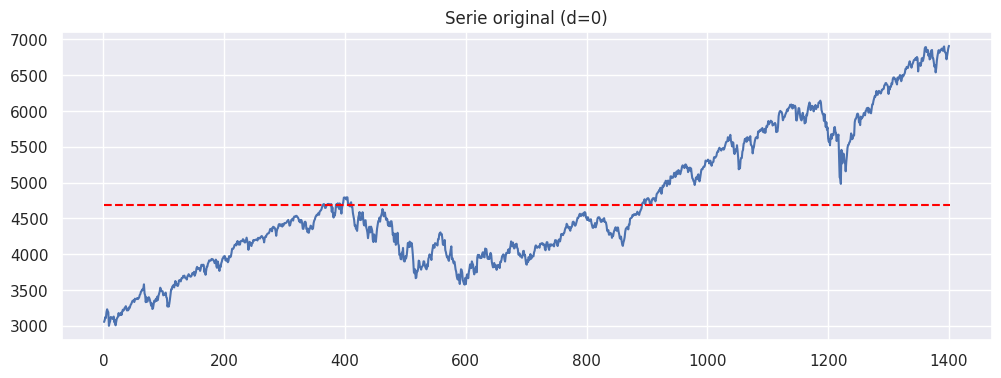

In [10]:
# Serie original
prueba_diferenciacion(df_tr['y'], 0, 'Serie original (d=0)')

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


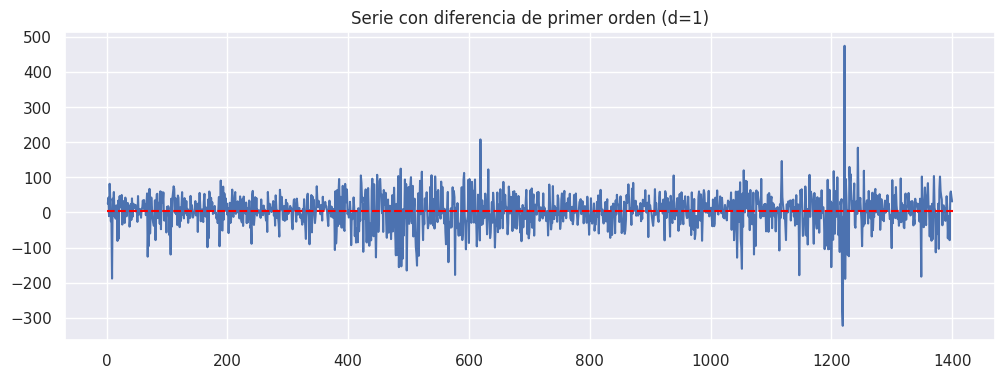

In [11]:
# Serie con d=1
prueba_diferenciacion(df_tr['y'], 1, 'Serie con diferencia de primer orden (d=1)')

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


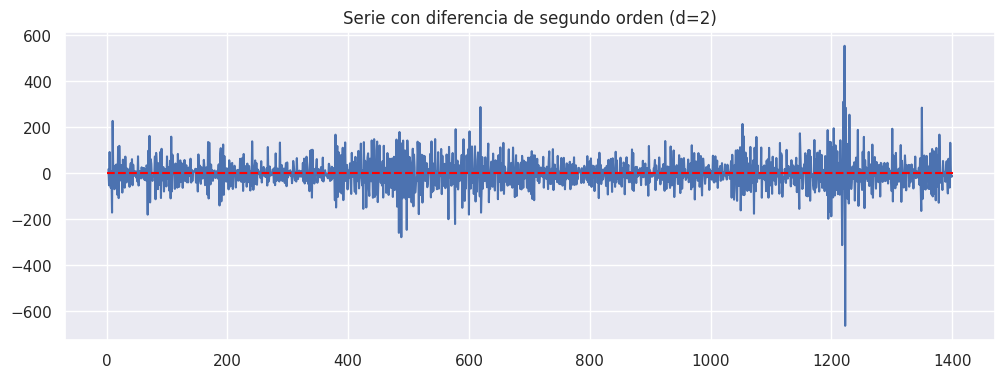

In [12]:
# Serie con d=2
prueba_diferenciacion(df_tr['y'], 2, 'Serie con diferencia de segundo orden (d=2)')

Y vemos que con d=1 o d=2 logramos obtener una Serie Estacionaria.

Así que **usaremos d=1 (el orden de diferenciación más bajo posible)**.

Ahora haremos el gráfico de la ACF (para determinar el orden "q") y de la PACF (para determinar el orden "p"). Estos dos gráficos se obtienen a partir de la primera diferencia:

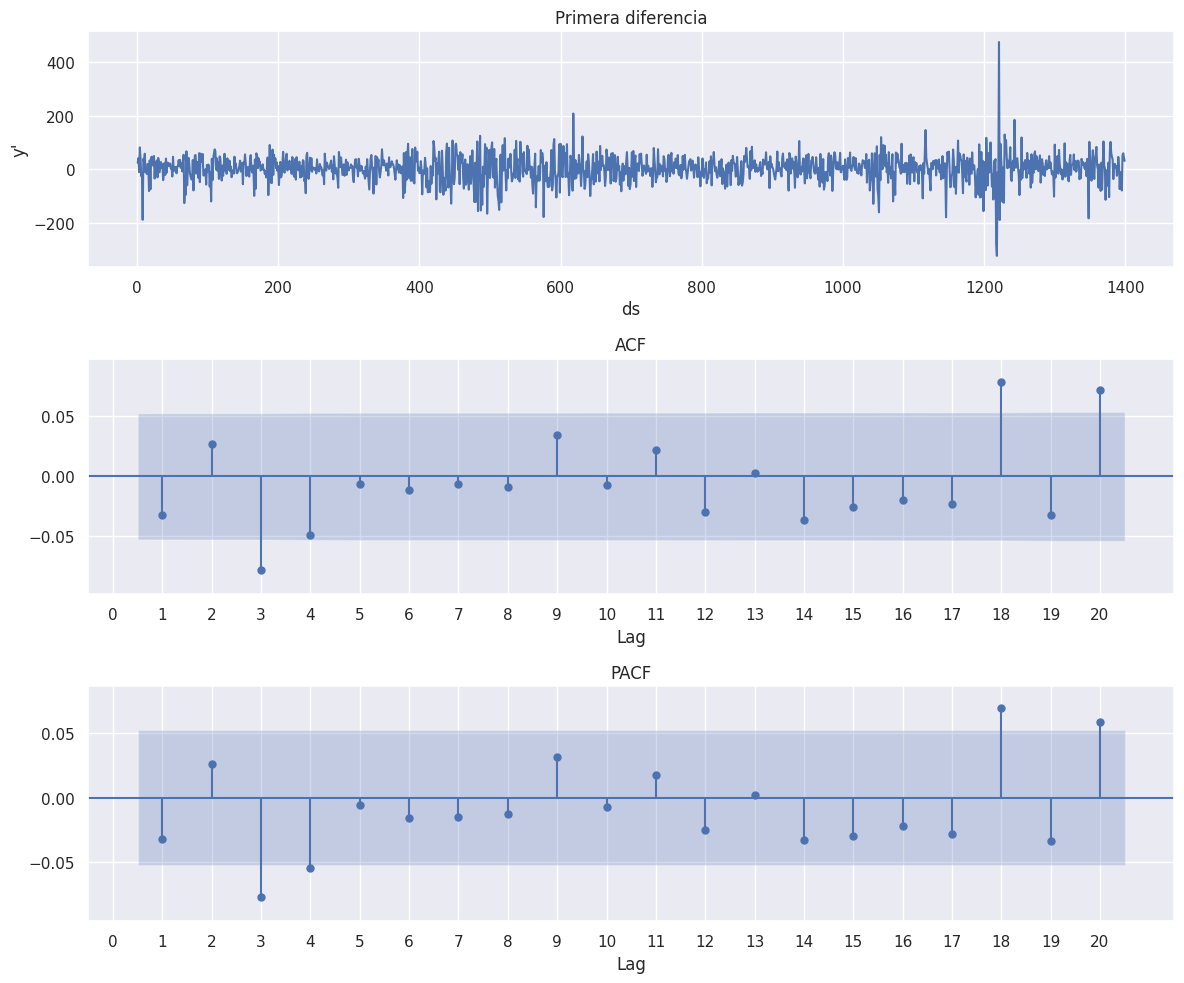

In [13]:
# Calcular primera diferencia de la Serie
df_dif1 = df_tr['y'].diff().dropna()

# Dibujar serie diferenciada, función de autocorrelación y PACF
fig, axs = plt.subplots(3,1,figsize=(12,10))

sns.lineplot(df_dif1[:], ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Primera diferencia')

LAGS = 20
plot_acf(df_dif1,
         alpha=0.05, # Intervalo de confianza del 95%
         lags=LAGS,
         zero=False,
         auto_ylims=True,
         ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
#axs[1].set_ylim([-0.2, 1.3])
axs[1].grid(True)

plot_pacf(df_dif1,
          alpha=0.05, # Intervalo de confianza del 95%
          lags=LAGS,
          zero=False,
          auto_ylims=True,
          ax=axs[2])
axs[2].set_xlabel('Lag')
axs[2].set_xticks(range(0,LAGS+1))
axs[2].set_title('PACF')
#axs[2].set_ylim([-0.2, 1.3])
axs[2].grid(True)

plt.tight_layout()


**Observaciones:**
- En la ACF al parecer q=3 o q=4 podrían resultar adecuados (q=4 está al límite)
- En la PACF al parecer p=3 o p=4 podrían resultar adecuados

En este caso, simplemente observando las gráficas, no podemos decidir claramente entre una opción y la otra. Así que la solución es hacer un **ajuste de hiper-parámetros del modelo ARIMA**:

1. Elegimos una **grilla de hiper-parámetros**
2. Por cada combinación de hiper-parámetros entrenamos y validamos los modelos correspondientes
3. Y elegimos, de ser posible, los parámetros con el mejor desempeño

Y acá es importante introducir un criterio importante (que aplica para modelos ARIMA pero en general para cualquier modelo predictivo):

> En caso de obtener desempeños similares se sugiere usar el modelo más simple (con menos hiper-parámetros) posible

Así que además de considerar modelos con los posibles valores de p y q encontrados anteriormente, consideraremos modelos aún más simples.

Estos serán los rangos de valores a considerar:

- $p = \{0, 1, 2, 3, 4\}$
- $d = 1$
- $q = \{0, 1, 2, 3, 4\}$

Comencemos creando las diferentes instancias de estos modelos en StatsForecast:

In [14]:
# Rangos de valores de los hiper-parámetros
ps = range(0, 5) # [0, 1, 2, 3, 4]
qs = range(0, 5) # [0, 1, 2, 3, 4]
d = 1

# Crear lista de modelos StatsForecast
modelos = [
    ARIMA(
        order=(p, d, q),
        alias=f'ARIMA({p},{d},{q})',
        include_constant=False # Común en acciones en la bolsa para que no haya tendencia creciente
    )
    for p in ps
    for q in qs
]

# Crear instancias
# n_jobs=-1 para usar todas las CPUs al entrenar los 25 modelos en paralelo
sf = StatsForecast(
    models=modelos,
    freq='B',  # "B" (business day, días laborales)
    n_jobs=-1
)

print(f"Se crearon {len(modelos)} modelos.")
modelos

Se crearon 25 modelos.


[ARIMA(0,1,0),
 ARIMA(0,1,1),
 ARIMA(0,1,2),
 ARIMA(0,1,3),
 ARIMA(0,1,4),
 ARIMA(1,1,0),
 ARIMA(1,1,1),
 ARIMA(1,1,2),
 ARIMA(1,1,3),
 ARIMA(1,1,4),
 ARIMA(2,1,0),
 ARIMA(2,1,1),
 ARIMA(2,1,2),
 ARIMA(2,1,3),
 ARIMA(2,1,4),
 ARIMA(3,1,0),
 ARIMA(3,1,1),
 ARIMA(3,1,2),
 ARIMA(3,1,3),
 ARIMA(3,1,4),
 ARIMA(4,1,0),
 ARIMA(4,1,1),
 ARIMA(4,1,2),
 ARIMA(4,1,3),
 ARIMA(4,1,4)]

Ahora la idea es validar cada uno de estos modelos usando la validación cruzada. En este caso reutilizaremos la función "metricas_cv" que creamos anteriormente:

In [15]:
# Tabla de validación cruzada para cada modelo
cv_df = sf.cross_validation(
    df=df_tr,
    h=5,
    step_size=10,
    n_windows=24
)
cv_df

,unique_id,ds,cutoff,y,"ARIMA(0,1,0)","ARIMA(0,1,1)","ARIMA(0,1,2)","ARIMA(0,1,3)","ARIMA(0,1,4)","ARIMA(1,1,0)",...,"ARIMA(3,1,0)","ARIMA(3,1,1)","ARIMA(3,1,2)","ARIMA(3,1,3)","ARIMA(3,1,4)","ARIMA(4,1,0)","ARIMA(4,1,1)","ARIMA(4,1,2)","ARIMA(4,1,3)","ARIMA(4,1,4)"
0,S&P 500,2025-01-17,2025-01-16,5996.660156,5937.339844,5937.313147,5935.983163,5935.482720,5935.411505,5937.314241,...,5935.707245,5936.426578,5936.975369,5942.037924,5938.210185,5935.350103,5935.873785,5934.667799,5934.550948,5939.721472
1,S&P 500,2025-01-21,2025-01-16,6049.240234,5937.339844,5937.313147,5936.141401,5930.191723,5930.138512,5937.314189,...,5930.429191,5931.286273,5932.149947,5937.889861,5933.978860,5929.877435,5930.410883,5930.432092,5931.226163,5938.871222
2,S&P 500,2025-01-22,2025-01-16,6086.370117,5937.339844,5937.313147,5936.141401,5930.840861,5929.148845,5937.314189,...,5931.079916,5929.495173,5931.534644,5937.881954,5932.231311,5928.562995,5928.432558,5925.939531,5926.992532,5939.670584
3,S&P 500,2025-01-23,2025-01-16,6118.709961,5937.339844,5937.313147,5936.141401,5930.840861,5929.375430,5937.314189,...,5931.226544,5928.774558,5930.210644,5940.203474,5935.184204,5928.973216,5928.165331,5925.897986,5926.052042,5939.586199
4,S&P 500,2025-01-24,2025-01-16,6101.240234,5937.339844,5937.313147,5936.141401,5930.840861,5929.375430,5937.314189,...,5931.486610,5928.698715,5929.980391,5935.197097,5929.459231,5929.310731,5928.398612,5929.465399,5928.684276,5937.459611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,S&P 500,2025-12-17,2025-12-16,6721.430176,6800.259766,6800.736628,6800.235645,6806.448487,6805.672312,6800.750711,...,6805.889685,6805.162726,6805.163504,6805.974595,6805.632356,6805.387393,6804.998405,6804.411771,6804.311862,6791.682886
116,S&P 500,2025-12-18,2025-12-16,6774.759766,6800.259766,6800.736628,6799.817181,6806.857679,6809.535085,6800.735878,...,6806.103841,6807.536935,6807.466582,6809.280538,6808.780276,6809.211659,6808.534320,6808.143672,6807.815819,6794.617207
117,S&P 500,2025-12-19,2025-12-16,6834.500000,6800.259766,6800.736628,6799.817181,6807.914986,6810.861182,6800.736327,...,6807.462737,6810.199911,6810.133733,6809.971885,6809.938768,6811.011513,6810.993905,6810.563240,6810.360827,6803.495900
118,S&P 500,2025-12-22,2025-12-16,6878.490234,6800.259766,6800.736628,6799.817181,6807.914986,6811.352727,6800.736313,...,6807.011922,6810.954937,6810.901771,6810.523874,6811.225236,6811.463818,6811.672287,6810.258603,6810.194811,6801.904023


In [16]:
# Y consolidar promedios y desviaciiones estándar del desempeño de cada modelo
alias_modelos = [m.alias for m in modelos]
metricas_modelos = metricas_cv(cv_df, alias_modelos)
metricas_modelos

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
0,"ARIMA(0,1,0)",82.381626,67.544660,1.145956,1.044529
1,"ARIMA(0,1,1)",82.546038,67.406335,1.148168,1.042668
2,"ARIMA(0,1,2)",82.270006,67.695842,1.144081,1.047599
3,"ARIMA(0,1,3)",84.841469,68.053592,1.185037,1.056862
4,"ARIMA(0,1,4)",85.610442,68.292808,1.191821,1.052697
5,"ARIMA(1,1,0)",82.548935,67.407631,1.148216,1.042740
6,"ARIMA(1,1,1)",83.018212,68.420764,1.156863,1.057293
7,"ARIMA(1,1,2)",82.936980,68.981575,1.155702,1.066130
8,"ARIMA(1,1,3)",85.836976,68.347618,1.199570,1.056834
9,"ARIMA(1,1,4)",85.925361,68.534905,1.198998,1.057071


¡Perfecto! Ahora podemos comparar los diferentes desempeños. Lo ideal es obtener un modelo con el RMSE/MAPE promedio y desviación más bajos posible.

Comencemos ordenando la tabla anterior de manera ascendente por RMSE promedio:

In [17]:
metricas_modelos.sort_values(by="RMSE_media")

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
2,"ARIMA(0,1,2)",82.270006,67.695842,1.144081,1.047599
10,"ARIMA(2,1,0)",82.310968,67.687431,1.144701,1.047873
0,"ARIMA(0,1,0)",82.381626,67.544660,1.145956,1.044529
1,"ARIMA(0,1,1)",82.546038,67.406335,1.148168,1.042668
5,"ARIMA(1,1,0)",82.548935,67.407631,1.148216,1.042740
11,"ARIMA(2,1,1)",82.576677,68.013462,1.150955,1.055485
7,"ARIMA(1,1,2)",82.936980,68.981575,1.155702,1.066130
6,"ARIMA(1,1,1)",83.018212,68.420764,1.156863,1.057293
12,"ARIMA(2,1,2)",83.516050,68.253550,1.161944,1.052835
15,"ARIMA(3,1,0)",84.648135,68.086235,1.182114,1.057803


Realmente, los top-10 modelos tienen RMSEs (promedio y desviaciones) muy similares. Tomaremos los top-3:

- ARIMA(0,1,2)
- ARIMA(2,1,0)
- ARIMA(0,1,0)

Veamos ahora qué ocurre con los mejores modelos ordenados por MAPE:

In [18]:
metricas_modelos.sort_values(by="MAPE_media(%)")

,Modelo,RMSE_media,RMSE_std,MAPE_media(%),MAPE_std(%)
2,"ARIMA(0,1,2)",82.270006,67.695842,1.144081,1.047599
10,"ARIMA(2,1,0)",82.310968,67.687431,1.144701,1.047873
0,"ARIMA(0,1,0)",82.381626,67.544660,1.145956,1.044529
1,"ARIMA(0,1,1)",82.546038,67.406335,1.148168,1.042668
5,"ARIMA(1,1,0)",82.548935,67.407631,1.148216,1.042740
11,"ARIMA(2,1,1)",82.576677,68.013462,1.150955,1.055485
7,"ARIMA(1,1,2)",82.936980,68.981575,1.155702,1.066130
6,"ARIMA(1,1,1)",83.018212,68.420764,1.156863,1.057293
12,"ARIMA(2,1,2)",83.516050,68.253550,1.161944,1.052835
15,"ARIMA(3,1,0)",84.648135,68.086235,1.182114,1.057803


También son muy similares los desempeños y de hecho los top-3 siguen siendo los mismos del caso anterior:

- ARIMA(0,1,2)
- ARIMA(2,1,0)
- ARIMA(0,1,0)

Así que ahora la idea es intentar determinar cuál de estos tres modelos resulta más adecuado, más allá del desempeño RMSE/MAPE que en últimas es muy bajo.

Comencemos haciendo el análisis de residuales de cada modelo. Crearemos una función donde especificaremos el orden (p,d,q) y obtendremos los gráficos para analizar dichos residuales:

In [19]:
def analizar_residuales(orden, data_tr):
    # Extraer p, q, d
    p, d, q = orden

    # Instancia del modelo
    model = [ARIMA(order=(p,d,q), alias=f"ARIMA({p},{d},{q})", include_constant=False)]
    sf = StatsForecast(models=model,
                       freq='B',
                      )

    # Entrenar con fit y extraer modelo
    sf.fit(data_tr)
    modelo_sf = sf.fitted_[0][0].model_

    # Extraer y graficar residuales en el tiempo, histograma y ACF
    res = modelo_sf['residuals']

    fig, axs = plt.subplots(4,1,figsize=(12,12))
    sns.lineplot(df_tr["y"], ax=axs[0])
    axs[0].set_title('Serie de tiempo original')

    sns.lineplot(res, ax=axs[1])
    axs[1].set_title('Residuales en el tiempo')

    sns.histplot(res, ax=axs[2])
    axs[2].set_title('Histograma de los residuales')

    plot_acf(res, ax=axs[3])
    axs[3].set_title('ACF de los residuales')
    axs[3].set_ylim([-0.5, 1.5])

    plt.tight_layout();

Y ahora obtengamos los gráficos de residuales de cada modelo:

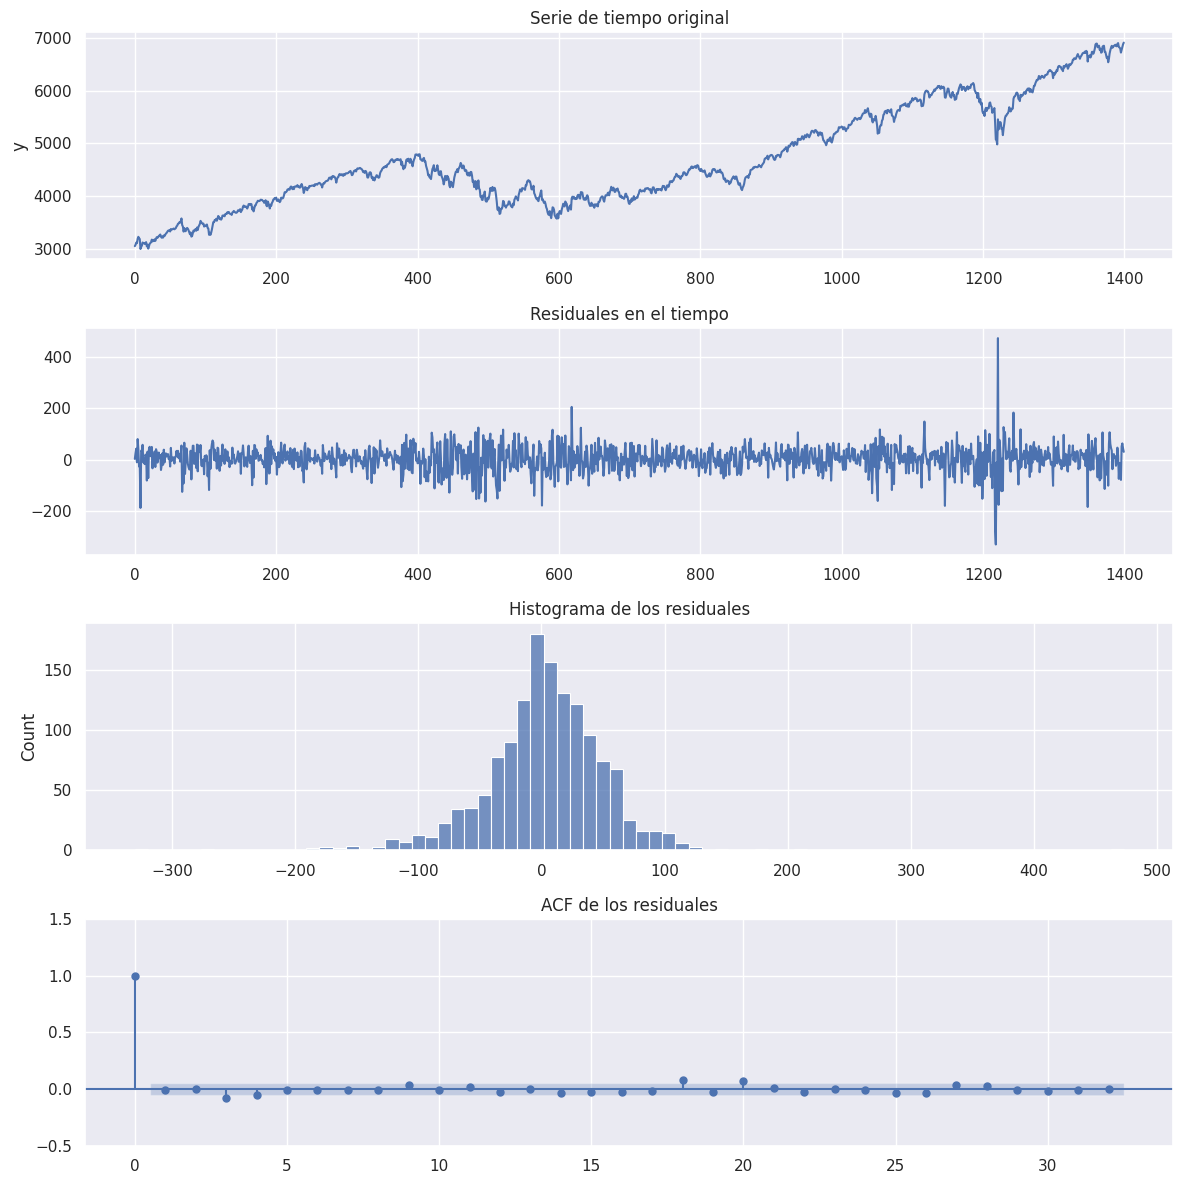

In [20]:
# ARIMA(0,1,2)
analizar_residuales(orden=(0,1,2), data_tr=df_tr)

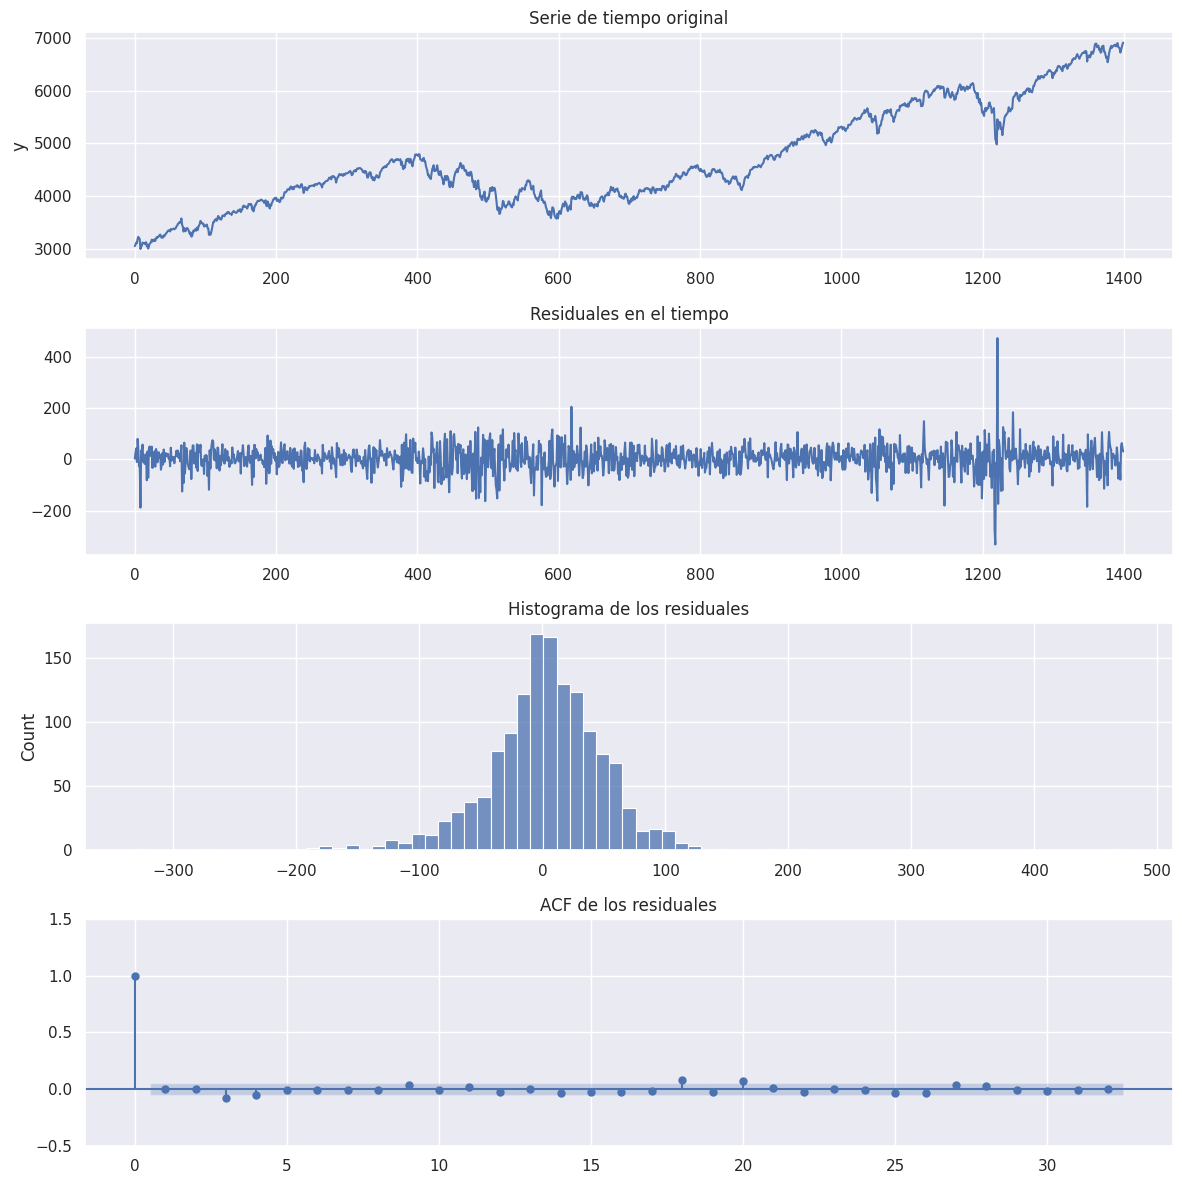

In [21]:
# ARIMA(2,1,0)
analizar_residuales(orden=(2,1,0), data_tr=df_tr)

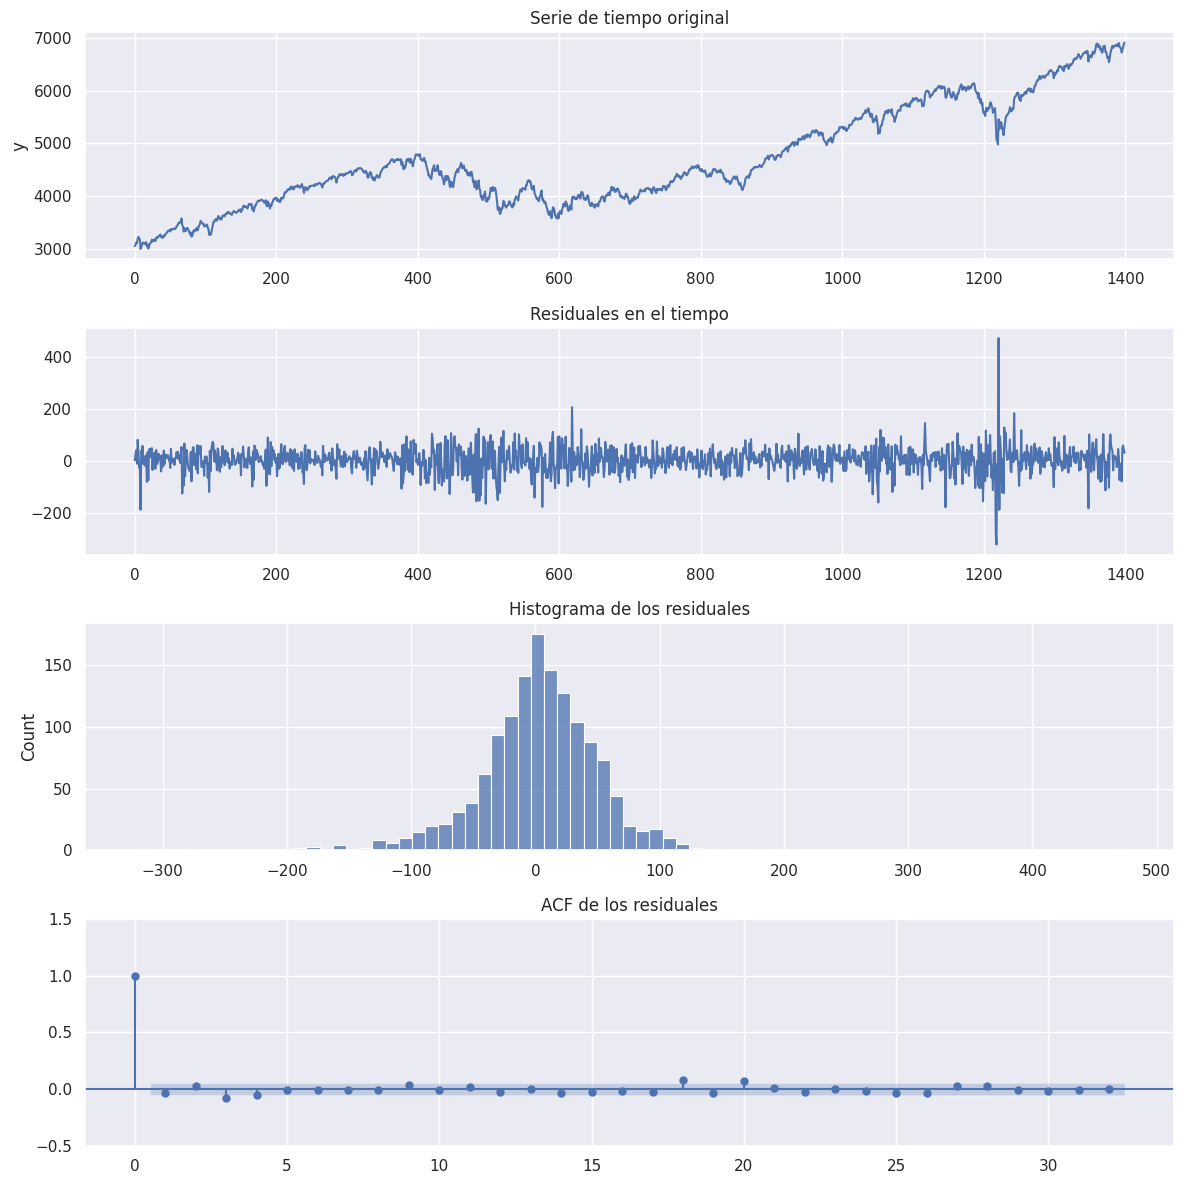

In [22]:
# ARIMA(0,1,0)
analizar_residuales(orden=(0,1,0), data_tr=df_tr)

En los tres casos vemos un comportamiento de los residuales cercano al ideal: media cercana a cero, distribución quasi-normal y sin patrones en la ACF.

Así que debemos definir otro criterio de desempate.

Podemos analizar estadísticamente los parámetros obtenidos para cada modelo usando "statsmodels". Por ejemplo, veamos los parámetros del modelo ARIMA(0,1,2):

In [23]:
modelo_sm = sm.tsa.ARIMA(df_tr['y'], order=(0,1,2), trend='n')
resultados = modelo_sm.fit()

# Imprimimos los valores p resultado de aplicar la prueba Wald
print("Valores p modelo ARIMA(0,1,2)")
resultados.pvalues

Valores p modelo ARIMA(0,1,2)


ma.L1     0.134097
ma.L2     0.218473
sigma2    0.000000
dtype: float64

En esta prueba:

- La hipótesis nula es que el parámetro es igual a cero (p > 0.05) y por tanto es prácticamente irrelevante
- La hipótesis alterna es que el parámetro es diferente de cero (p <= 0.05)

En este modelo vemos que ambos parámetros son estadísticamente iguales a cero (valores p > 0.05). Es decir que **el modelo ARIMA(0,1,2) es prácticamente equivalente a un modelo ARIMA(0,1,0)**

Veamos qué ocurre con el modelo ARIMA(2,1,0):

In [24]:
modelo_sm = sm.tsa.ARIMA(df_tr['y'], order=(2,1,0), trend='n')
resultados = modelo_sm.fit()

# Imprimimos los valores p resultado de aplicar la prueba Wald
print("Valores p modelo ARIMA(2,1,0)")
resultados.pvalues

Valores p modelo ARIMA(2,1,0)


ar.L1     0.075707
ar.L2     0.219077
sigma2    0.000000
dtype: float64

En este caso ocurre algo similar al anterior: ambos parámetros son estadísticamente iguales a cero. Es decir que **el modelo ARIMA(2,1,0) es prácticamente equivalente a un modelo ARIMA(0,1,0)**

¡Así que todo este análisis nos lleva a concluir que el modelo más adecuado en este caso es el ARIMA(0,1,0)!

¿No es contradictorio esto? Es decir, queríamos construir un modelo ARIMA y hemos llegado a que el mejor modelo no tiene componente auto-regresivo (p=0) ni componente de media móvil (q=0).

Simplemente imaginemos qué pasaría si p≠0 y/o q≠0: ¡habría patrones en la Serie y muchos serían millonarios!

Así que el modelo final es de la forma:

$$y'_t = \epsilon_t$$

Es decir:

$$y_t - y_{t-1} = \epsilon_t$$

Es decir que para predecir uno o múltiples valores a futuro simplemente tenemos en cuenta el último registro de la Serie:

$$y_t = y_{t-1} + \epsilon_t$$

## 8. Paso 7: validar el modelo y comparar su desempeño con el del modelo base (3)

Y si comparamos esto con el modelo base que hemos definido al comienzo de la lección **concluimos que el modelo que mejor pronostica el comportamiento de esta Serie es un modelo Näive que es exactamente igual a un modelo ARIMA(0,1,0)**

Recordemos que el desempeño de este modelo es:

- RMSE de 82.4 USD +- 67.5 USD
- MAPE de 1.14 +- 1.04 %

## 9. Paso 8: generar pronósticos con el modelo seleccionado en el paso anterior

Esto ya lo hicimos con el modelo Näive, el modelo base, pero hagámoslo nuevamente para el modelo ARIMA(0,1,0) (que en la práctica es exactamente el mismo).



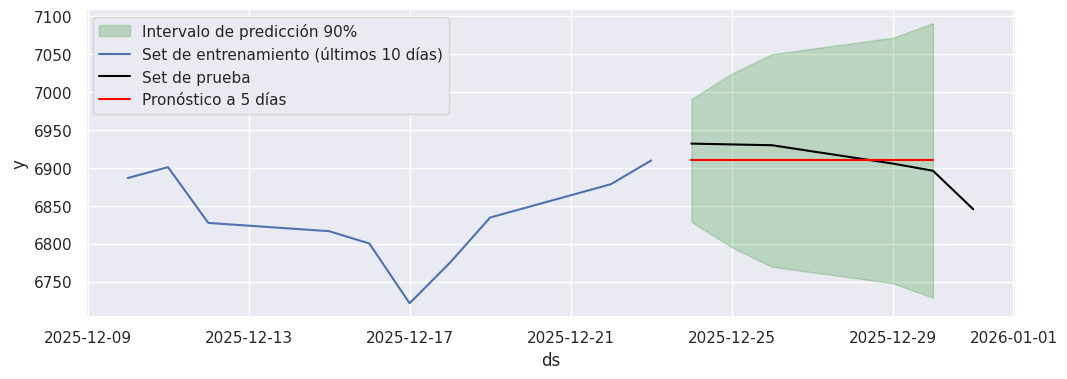

In [26]:
# Crear instancia del modelo ARIMA(0,1,0) y entrenarlo con los datos de entrenamiento
sf = StatsForecast(models = [ARIMA(order=(0,1,0), alias='ARIMA(0,1,0)')], freq='B')
sf.fit(df_tr)

# Pronóstico a 5 días laborales
fc = sf.forecast(df=df_tr, h=5, level=[90])

# Graficar última parte del set de entrenamiento, datos de prueba, pronóstico e intervalo de predicción
fig, ax = plt.subplots()
plt.fill_between(x=fc["ds"],
                y1 = fc['ARIMA(0,1,0)-lo-90'],
                y2 = fc['ARIMA(0,1,0)-hi-90'],
                color = 'green',
                alpha = 0.2,
                label = 'Intervalo de predicción 90%');
sns.lineplot(df_tr[-10:], x="ds", y="y", label='Set de entrenamiento (últimos 10 días)');
sns.lineplot(df_ts, x="ds", y="y", color='black', label='Set de prueba');
sns.lineplot(fc, x="ds", y="ARIMA(0,1,0)", color='red', label='Pronóstico a 5 días');